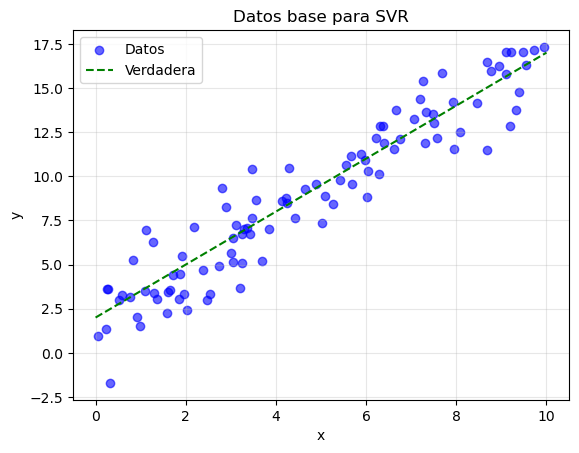

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Datos sintecticos para regrersion (lineal + ruido)
N = 100
x = np.sort(np.random.uniform(0, 10, N))
y = 2.0 + 1.5 * x + np.random.normal(0, 1.5, N)  # ruido moderado

x_test = np.linspace(0, 10, 300)
y_true = 2.0 + 1.5 * x_test

plt.scatter(x, y, color='blue', alpha=0.6, label='Datos')
plt.plot(x_test, y_true, 'g--', label='Verdadera')
plt.title('Datos base para SVR')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
def svr_fit(x, y, C=10, epsilon=0.5):
    """
    SVR lineal desde cero (dual formulation simplificada).
    Tecnología inversa: maximizamos margen + penalizamos violaciones > ε.
    """
    n = len(x)
    # Matriz de kernel lineal
    K = x[:, None] * x[None, :]  # x_i * x_j
    
    # Función objetivo dual
    def objective(alpha):
        return 0.5 * alpha @ K @ alpha - np.sum(alpha * y)
    
    # Restricciones simplificadas
    cons = (
        {'type': 'eq', 'fun': lambda alpha: np.sum(alpha)},
        {'type': 'ineq', 'fun': lambda alpha: C - alpha},
        {'type': 'ineq', 'fun': lambda alpha: alpha}
    )
    
    bounds = [(0, C) for _ in range(n)]
    
    from scipy.optimize import minimize
    res = minimize(objective, np.zeros(n), constraints=cons, bounds=bounds, method='SLSQP')
    alpha = res.x
    
    # Support vectors
    sv_idx = alpha > 1e-5
    sv_x = x[sv_idx]
    sv_y = y[sv_idx]  # ← CORRECCIÓN: agregar esta línea
    sv_alpha = alpha[sv_idx]
    
    # Intercepto b (promedio de soportes)
    b = np.mean(sv_y - sv_alpha @ (sv_x[:, None] * sv_x[None, :]))
    
    def predict(x_new):
        return b + np.sum(sv_alpha * (sv_x * x_new))
    
    return predict, sv_idx, sv_alpha, sv_x, sv_y  # ← Retorna también sv_y

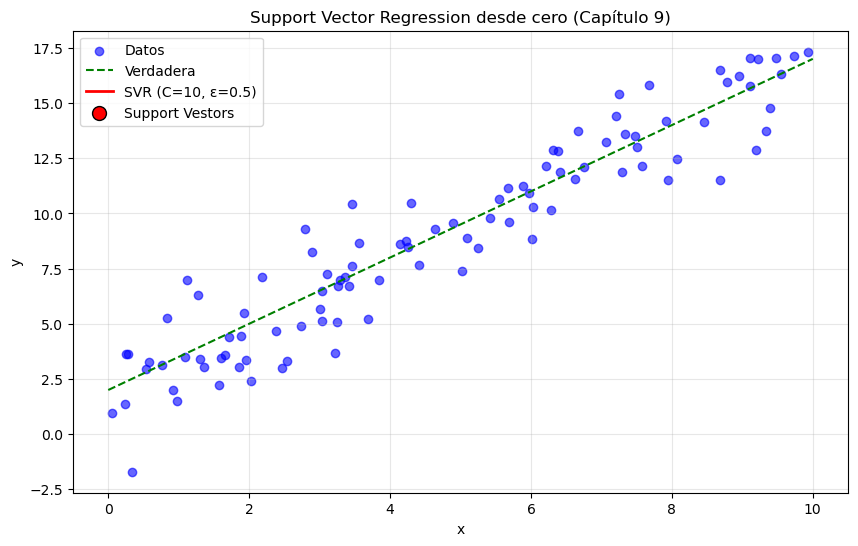

In [24]:
C = 10      # penalización (grande = margen estricto)
epsilon = 0.5  # tubo de insensitividad

predict_svr, sv_idx, sv_alpha, sv_x, sv_y = svr_fit(x, y, C=C, epsilon=epsilon)

y_pred_svr = np.array([predict_svr(xi) for xi in x_test])

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', alpha=0.6, label='Datos')
plt.plot(x_test, y_true, 'g--', label='Verdadera')
plt.plot(x_test, y_pred_svr, 'r-', linewidth=2, label=f'SVR (C={C}, ε={epsilon})')
plt.scatter(sv_x, sv_y,  color='red', s=100, edgecolors='black', label=('Support Vestors'))
plt.xlabel('x')
plt.ylabel('y')
plt.title('Support Vector Regression desde cero (Capítulo 9)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
def rbf_kernel(x1, x2, gamma=1.0):
    """
    Kenel RBF: K(x1, x2) = exp(-gamma ||x1 - x2||^2)
    Tecnologia inversa: Calcula distacias euclidianas en matriz (N,M) sin loop.
    """
    # Asegurar que x1 y x2 sean 2D (N,1) y (M,1)
    x1 = x1.reshape(-1, 1)
    x2 = x2.reshape(-1, 1)

    # Distancia al cuadrado ||x1 - x2||^2
    sq_dist = np.sum((x1[:, None] - x2[None, :])**2, axis=2) # axis=2 OK ahora (N,1,M,1) broadcast a (N,M,1)
    
    return np.exp(-gamma * sq_dist)

def svr_fit_kernel(x, y, C=10, epsilon=0.5, gamma=1.0):
    """
    SVR con kernel general (RBF en este caso).
    Extension del dual lineal: reemplazamos K lineal por K RBJ.
    """
    n = len(x)
    # Matriz del kernel RBF
    K = rbf_kernel(x, x, gamma=gamma)

    # Funcion objetivo dual (igual que lineal, solo cambia K)
    def objective(alpha):
        return 0.5 * alpha @ K @ alpha - np.sum(alpha * y)
    
    cons =(
        {'type': 'eq', 'fun': lambda alpha: np.sum(alpha)},
        {'type': 'ineq', 'fun': lambda alpha: C - alpha},
        {'type': 'ineq', 'fun': lambda alpha: alpha}
    )

    bounds = [(0, C) for _ in range(n)]

    from scipy.optimize import minimize
    res = minimize(objective, np.zeros(n), constraints=cons, bounds=bounds, method='SLSQP')
    alpha = res.x

    # Intercepto b (promedio de soportes)
    K_sv = rbf_kernel(sv_x, sv_x, gamma=gamma)
    b = np.mean(sv_y - sv_alpha @ K_sv)

    def predict(x_new):
        K_new = rbf_kernel(x_new.reshape(-1, 1), sv_x.reshape(-1, 1), gamma=gamma)
        return b + np.sum(sv_alpha * K_new.flatten())
    return predict, sv_idx, sv_alpha, sv_x, sv_y

c:\Users\Maria Clara\.conda\envs\mi-entorno\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Maria Clara\.conda\envs\mi-entorno\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


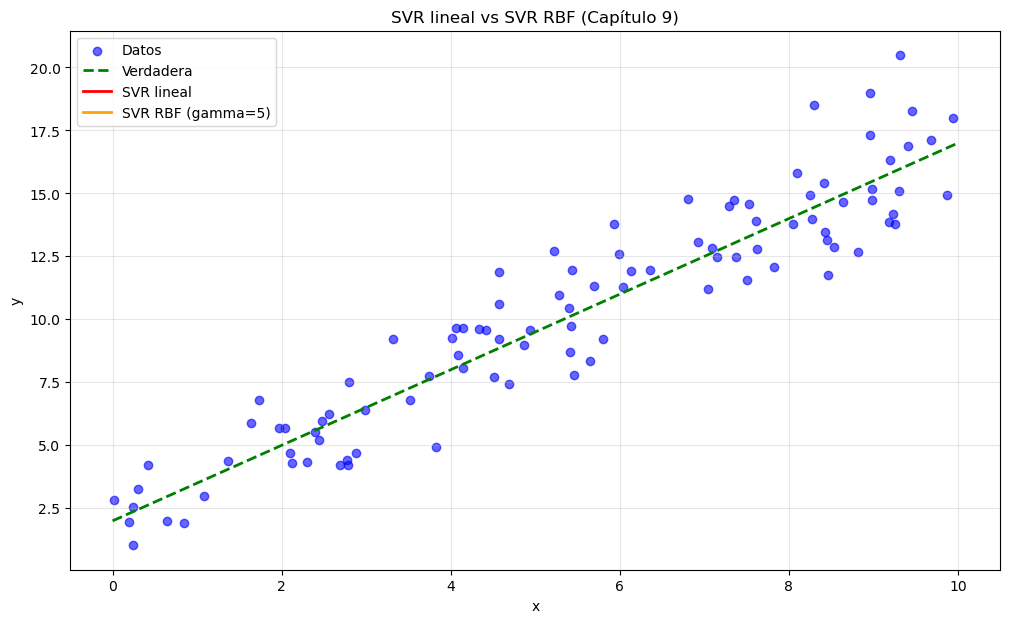

In [21]:
# SVR lineal (ya lo tienes)
predict_lin, sv_idx_lin, sv_alpha_lin, sv_x_lin, sv_y_lin = svr_fit(x, y, C=10, epsilon=1.0)
y_pred_lin = np.array([predict_lin(xi) for xi in x_test])

# SVR RBF
predict_rbf, sv_idx_rbf, sv_alpha_rbf, sv_x_rbf, sv_y_rbf = svr_fit_kernel(x, y, C=10, epsilon=1.0, gamma=5.0)
y_pred_rbf = np.array([predict_rbf(xi) for xi in x_test])

plt.figure(figsize=(12, 7))
plt.scatter(x, y, color='blue', alpha=0.6, label='Datos')
plt.plot(x_test, y_true, 'g--', linewidth=2, label='Verdadera')
plt.plot(x_test, y_pred_lin, 'r-', linewidth=2, label='SVR lineal')
plt.plot(x_test, y_pred_rbf, 'orange', linewidth=2, label='SVR RBF (gamma=5)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('SVR lineal vs SVR RBF (Capítulo 9)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

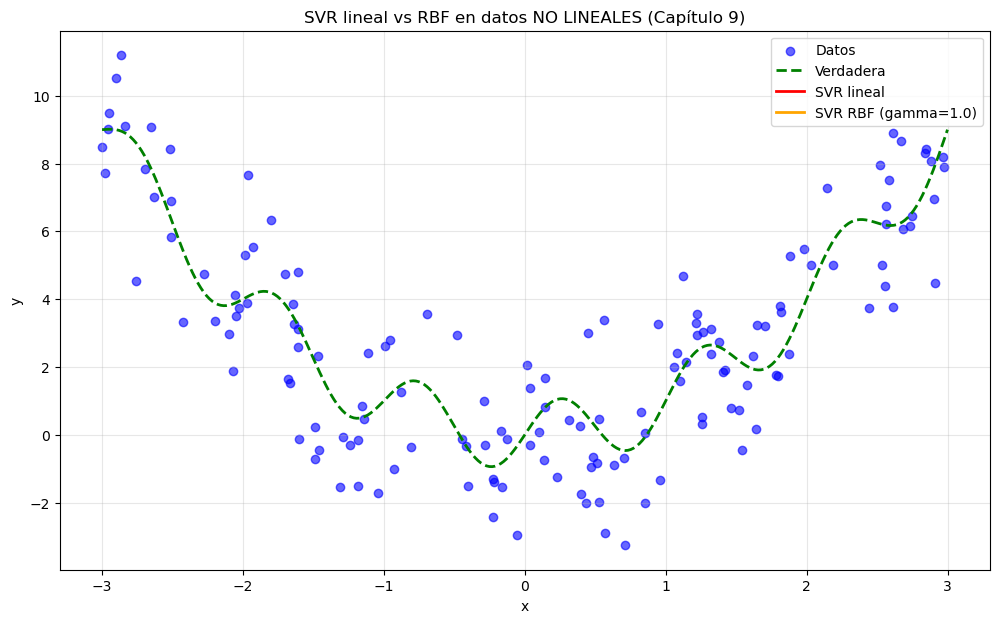

In [26]:
# Datos NO LINEALES (cuadrática + ondas + ruido)
x = np.sort(np.random.uniform(-3, 3, 150))
y = x**2 + np.sin(2 * np.pi * x) + np.random.normal(0, 1.5, 150)

x_test = np.linspace(-3, 3, 300)
y_true = x_test**2 + np.sin(2 * np.pi * x_test)

# SVR lineal (tu implementación)
predict_lin, sv_idx_lin, sv_alpha_lin, sv_x_lin, sv_y_lin = svr_fit(x, y, C=10, epsilon=1.0)
y_pred_lin = np.array([predict_lin(xi) for xi in x_test])

# SVR RBF (tu implementación corregida)
predict_rbf, sv_idx_rbf, sv_alpha_rbf, sv_x_rbf, sv_y_rbf = svr_fit_kernel(x, y, C=10, epsilon=1.0, gamma=1.0)
y_pred_rbf = np.array([predict_rbf(xi) for xi in x_test])

plt.figure(figsize=(12, 7))
plt.scatter(x, y, color='blue', alpha=0.6, label='Datos')
plt.plot(x_test, y_true, 'g--', linewidth=2, label='Verdadera')
plt.plot(x_test, y_pred_lin, 'r-', linewidth=2, label='SVR lineal')
plt.plot(x_test, y_pred_rbf, 'orange', linewidth=2, label='SVR RBF (gamma=1.0)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('SVR lineal vs RBF en datos NO LINEALES (Capítulo 9)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()